In [ ]:
After preprocessing: - we start with:
* XGBoost
Then:
1. train model 
2. evaluate RMSE/MAE 
3. compare forecasts 
4. visualize predictions 
This becomes our full AI inflation forecasting system.


In [11]:
pip install xgboost scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 351.8 kB/s  0:00:07 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt


In [5]:
# Load our processed data
df = pd.read_csv("Processed_Data_ML.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Date                          158 non-null    datetime64[ns]
 1   Inflation                     158 non-null    float64       
 2   Inflation_Lag1                158 non-null    float64       
 3   Food_Inflation                158 non-null    float64       
 4   Exchange_Change               158 non-null    float64       
 5   Exchange_Change_Lag1          158 non-null    float64       
 6   Policy_Rate                   158 non-null    float64       
 7   TBill_91D                     158 non-null    float64       
 8   Target_Food_Inflation_Month1  157 non-null    float64       
 9   Target_Food_Inflation_Month2  156 non-null    float64       
 10  Target_Food_Inflation_Month3  155 non-null    float64       
dtypes: datetime64[ns](1), float64(10

In [6]:
df.head()

,Date,Inflation,Inflation_Lag1,Food_Inflation,Exchange_Change,Exchange_Change_Lag1,Policy_Rate,TBill_91D,Target_Food_Inflation_Month1,Target_Food_Inflation_Month2,Target_Food_Inflation_Month3
0,2013-02-01,12.120296,11.814164,6.175472,-0.418346,0.420103,12.0,12.144490,6.260989,6.530455,6.583939
1,2013-03-01,12.149440,12.120296,6.260989,2.060200,-0.418346,12.0,12.216735,6.530455,6.583939,6.676119
2,2013-04-01,12.990894,12.149440,6.530455,1.926987,2.060200,12.0,12.288980,6.583939,6.676119,7.079580
3,2013-05-01,13.828194,12.990894,6.583939,3.747921,1.926987,14.0,12.361224,6.676119,7.079580,7.117053
4,2013-06-01,14.049153,13.828194,6.676119,4.908226,3.747921,18.0,12.433469,7.079580,7.117053,7.231465


In [7]:
# The very last row of our data contains today's real-world clues, but its 'Target_Inflation_Month1' is NaN because next month hasn't happened yet.
# For training the AI, we ONLY want rows where the future answer is KNOWN.
# Therefore, we drop rows where features OR targets are missing.

features = ['Inflation', 'Inflation_Lag1', 'Food_Inflation', 'Exchange_Change','Exchange_Change_Lag1', 'Policy_Rate', 'TBill_91D']
target = 'Target_Food_Inflation_Month1'

# Drop any row that has a NaN in our specific feature or target columns
ml_data = df.dropna(subset=features + [target]).copy()
ml_data.tail()

,Date,Inflation,Inflation_Lag1,Food_Inflation,Exchange_Change,Exchange_Change_Lag1,Policy_Rate,TBill_91D,Target_Food_Inflation_Month1,Target_Food_Inflation_Month2,Target_Food_Inflation_Month3
152,2025-10-01,5.170141,5.969097,6.539318,0.150402,0.021623,17.0,11.84,5.546341,4.675281,4.028840
153,2025-11-01,4.417512,5.170141,5.546341,0.123912,0.150402,17.0,16.18,4.675281,4.028840,3.418309
154,2025-12-01,3.754798,4.417512,4.675281,0.374711,0.123912,17.0,16.18,4.028840,3.418309,3.178128
155,2026-01-01,2.933188,3.754798,4.028840,0.000000,0.374711,17.0,16.18,3.418309,3.178128,NaN
156,2026-02-01,2.359477,2.933188,3.418309,0.000000,0.000000,17.0,16.18,3.178128,NaN,NaN


In [8]:
# SELECT OUR FEATURES AND OUR TARGET
# We use today's indicators as our inputs (X)
features = ['Inflation', 'Inflation_Lag1', 'Food_Inflation', 'Exchange_Change','Exchange_Change_Lag1', 'Policy_Rate', 'TBill_91D']
X = ml_data[features]

# We choose 1-Month Ahead Food Inflation as our target answer key (y)
y = ml_data['Target_Food_Inflation_Month1']

# CHRONOLOGICAL TRAIN-TEST SPLIT 
# We use the final 24 months of historical records as our test window
X_train = X.iloc[:-24]
y_train = y.iloc[:-24]

X_test = X.iloc[-24:]
y_test = y.iloc[-24:]

In [10]:
# INITIALIZING AND TRAINING THE XGBOOST REGRESSOR
# 'n_estimators' is the number of trees built in the correction chain
# 'learning_rate' controls how aggressively each tree corrects the previous one
model_month = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42)

model_month.fit(X_train, y_train)
print("Model training complete!")

Model training complete!


In [11]:
# GENERATE PREDICTIONS ON YOUR TEST WINDOW
predictions = model_month.predict(X_test)

# EVALUATE HOW ACCURATE THE MODEL IS
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"Evaluation Results for month1")
print(f"Mean Absolute Error (MAE): {mae:.2f}%")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}%")

Evaluation Results for month1
Mean Absolute Error (MAE): 1.65%
Root Mean Squared Error (RMSE): 2.03%


In [ ]:
How to Expand This to Month2 and Month3 Horizons: 
To predict further into the future, you don't need to change your features (X). You simply swap out the target variable (y) 
and train a new model

In [118]:
# 2. Define Inputs and explicit MONTH 2 Target
features = ['Inflation', 'Inflation_Lag1', 'Food_Inflation', 'Exchange_Change','Exchange_Change_Lag1', 'Policy_Rate', 'TBill_91D']
target_m2 = 'Target_Food_Inflation_Month2' 

# Clean dataset specifically for Month 2 boundaries
df_m2 = df.dropna(subset=features + [target_m2]).copy()

X_m2 = df_m2[features]
y_m2 = df_m2[target_m2]

# 3. Chronological Split using Month 2 variables
X_train_m2, X_test_m2 = X_m2.iloc[:-24], X_m2.iloc[-24:]
y_train_m2, y_test_m2 = y_m2.iloc[:-24], y_m2.iloc[-24:]

# 4. Train Month 2 Model
model_month2 = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42)
model_month2.fit(X_train_m2, y_train_m2)

# 5. Predict using Month 2 Model
predictions_m2 = model_month2.predict(X_test_m2)

# 6. Evaluate using ONLY Month 2 arrays
mae_m2 = mean_absolute_error(y_test_m2, predictions_m2)
rmse_m2 = np.sqrt(mean_squared_error(y_test_m2, predictions_m2))

print(f"Month 2 Evaluation Results")
print(f"Mean Absolute Error (MAE): {mae_m2:.2f}%")
print(f"Root Mean Squared Error (RMSE): {rmse_m2:.2f}%")

Month 2 Evaluation Results
Mean Absolute Error (MAE): 1.99%
Root Mean Squared Error (RMSE): 2.52%


In [116]:
# Define Inputs and explicit MONTH 3 Target
features = ['Inflation', 'Inflation_Lag1', 'Food_Inflation', 'Exchange_Change','Exchange_Change_Lag1', 'Policy_Rate', 'TBill_91D']
target_m3 = 'Target_Food_Inflation_Month3' 

# Clean dataset specifically for Month 3 boundaries
df_m3 = df.dropna(subset=features + [target_m3]).copy()

X_m3 = df_m3[features]
y_m3 = df_m3[target_m3]

# 3. Chronological Split using Month 3 variables
X_train_m3, X_test_m3 = X_m3.iloc[:-24], X_m3.iloc[-24:]
y_train_m3, y_test_m3 = y_m3.iloc[:-24], y_m3.iloc[-24:]

# 4. Train Month 3 Model
model_month3 = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42)

model_month3.fit(X_train_m3, y_train_m3)
print("Month 3 Model trained successfully!")

# 5. Predict using Month 3 Model
predictions_m3 = model_month3.predict(X_test_m3)

# 6. Evaluate using ONLY Month 3 arrays
mae_m3 = mean_absolute_error(y_test_m3, predictions_m3)
rmse_m3 = np.sqrt(mean_squared_error(y_test_m3, predictions_m3))

print(f"\nMonth 3 Evaluation Results")
print(f"Mean Absolute Error (MAE): {mae_m3:.2f}%")
print(f"Root Mean Squared Error (RMSE): {rmse_m3:.2f}%")

Month 3 Model trained successfully!

Month 3 Evaluation Results
Mean Absolute Error (MAE): 2.85%
Root Mean Squared Error (RMSE): 3.47%


In [ ]:
Our Month 2 errors will be slightly higher than Month 1. 
This happens naturally because predicting further out into the future means economic signals weaken, 
making it harder for the trees to guess with perfect precision.

In [ ]:
#Compare forecasts
Month 1	- Highest Accuracy - Lowest MAE / RMSE
Month 2 - Moderate Accuracy	- Slightly Higher MAE / RMSE
Month 3	- Lowest Accuracy - Highest MAE / RMSE

Why does this happen?
Think of it like weather forecasting: it is much easier for the algorithm to predict if it will rain tomorrow (Month 1)
based on today's clouds, than it is to predict if it will rain exactly three Tuesdays from now (Month 3).

Over a 3-month window, sudden economic shocks—like an unpredicted global shipping delay or an unannounced central bank policy shift—can 
occur that our current features simply couldn't see coming. Seeing our error rates gradually climb across Month 1, 2, and 3 is 
proof that our code is working perfectly and reflecting real economic uncertainty!

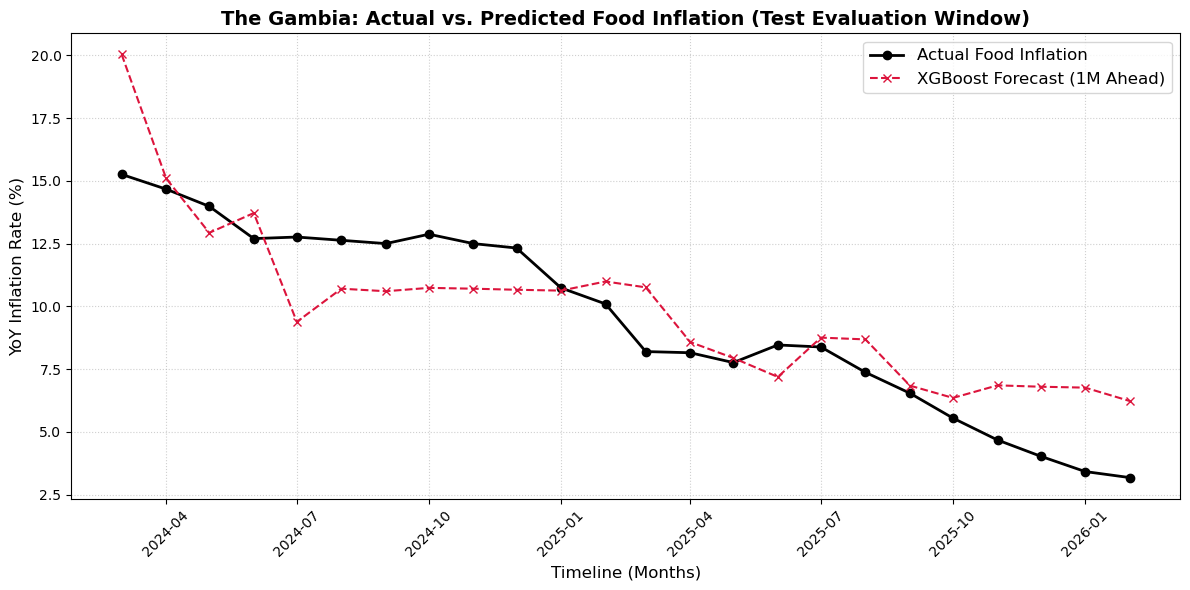

In [132]:
# VISUALIZE PREDICTIONS VS ACTUALS - MONTH 1
plt.figure(figsize=(12, 6))
test_dates = ml_data['Date'].iloc[-24:]
plt.plot(test_dates, y_test.values, label='Actual Food Inflation', color='black', linewidth=2, marker='o')
plt.plot(test_dates, predictions, label='XGBoost Forecast (1M Ahead)', color='crimson', linestyle='--', marker='x')

plt.title('The Gambia: Actual vs. Predicted Food Inflation (Test Evaluation Window)', fontsize=14, fontweight='bold')
plt.xlabel('Timeline (Months)', fontsize=12)
plt.ylabel('YoY Inflation Rate (%)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

# Show the chart directly on your screen
plt.show()

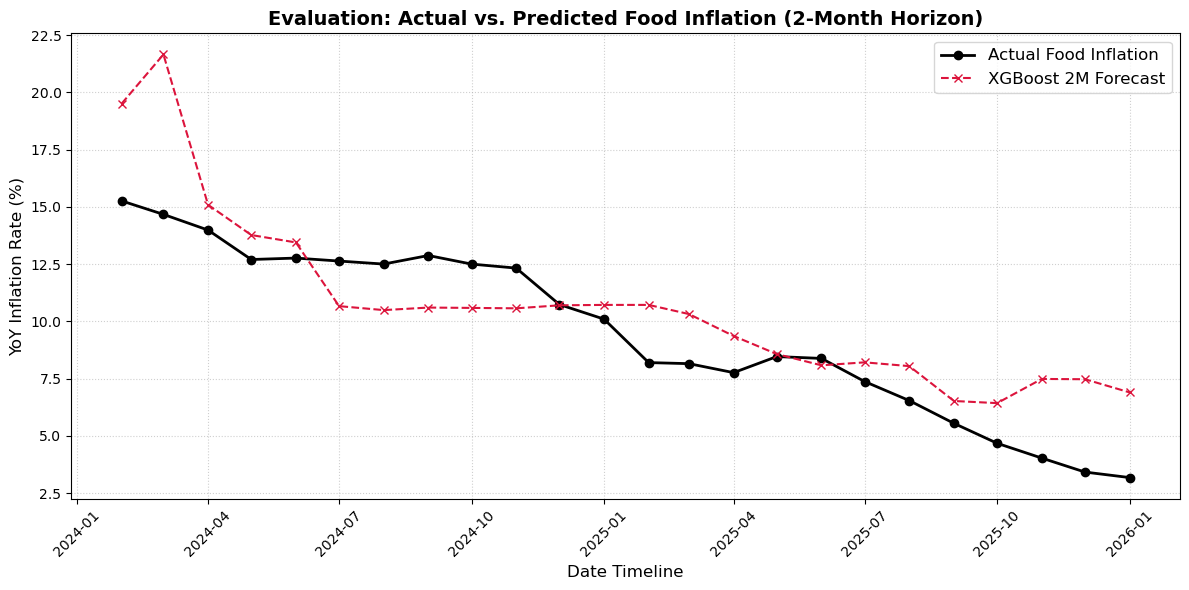

In [120]:
# MONTH 2
# Retrieve the actual dates for your test window (the last 24 months of df_m3)
test_dates_m2 = df_m2['Date'].iloc[-24:]

plt.figure(figsize=(12, 6))

# Plot the real answers
plt.plot(test_dates_m2, y_test_m2.values, label='Actual Food Inflation', color='black', linewidth=2, marker='o')

# Plot your XGBoost guesses
plt.plot(test_dates_m2, predictions_m2, label='XGBoost 2M Forecast', color='crimson', linestyle='--', marker='x')

plt.title('Evaluation: Actual vs. Predicted Food Inflation (2-Month Horizon)', fontsize=14, fontweight='bold')
plt.xlabel('Date Timeline', fontsize=12)
plt.ylabel('YoY Inflation Rate (%)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

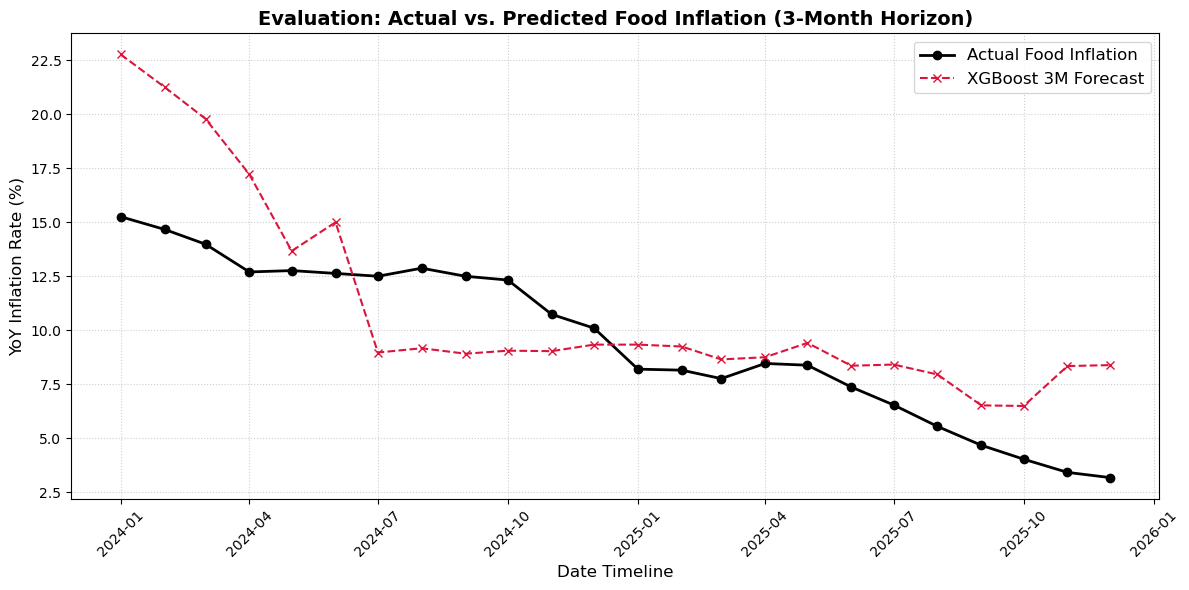

In [117]:
# MONTH 3
# Retrieve the actual dates for your test window (the last 24 months of df_m3)
test_dates_m3 = df_m3['Date'].iloc[-24:]

plt.figure(figsize=(12, 6))

# Plot the real answers
plt.plot(test_dates_m3, y_test_m3.values, label='Actual Food Inflation', color='black', linewidth=2, marker='o')

# Plot your XGBoost guesses
plt.plot(test_dates_m3, predictions_m3, label='XGBoost 3M Forecast', color='crimson', linestyle='--', marker='x')

plt.title('Evaluation: Actual vs. Predicted Food Inflation (3-Month Horizon)', fontsize=14, fontweight='bold')
plt.xlabel('Date Timeline', fontsize=12)
plt.ylabel('YoY Inflation Rate (%)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [14]:
import joblib

# Run this in your notebook to save your models to files
joblib.dump(model_month, "xgboost_model_m1.pkl")

['xgboost_model_m1.pkl']